In [1]:
import os as os
import itertools
import pandas as pd
import numpy as np
from scipy import stats
from scipy import special
from scipy.optimize import linear_sum_assignment
from MLstatkit.stats import Delong_test

from sklearn.metrics import auc, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

### Data Preparation

In [2]:
featuresGTV_df = pd.read_excel("radiomicsFeatures/features_GTV.xlsx", index_col=0)
featuresTRAD_df = pd.read_excel("radiomicsFeatures/features_TRAD.xlsx", index_col=0)

FEATURES = [feat for feat in featuresGTV_df.columns if "original" in feat]

### Feature Filtering

Removing features with near 0 variance

In [3]:

def filter_near_zero(df, threshold = 1e-3):
    feats = df.columns.to_list()
    feats_var = df.var()
    mask_feats = feats_var[feats_var<=threshold].index.to_list()
    selected_feats = [feat for feat in feats if feat not in mask_feats]
    print(f"Deleted {len(mask_feats)}/{len(feats)} near zero features, remaining {len(selected_feats)} features")
    return selected_feats

Removing highly correlated features

In [4]:
def filter_high_corr(df, threshold=0.85):

    corr_matrix = df.corr(method='spearman').abs()
    mean_corr = corr_matrix.mean()
    ordered_feats = mean_corr.sort_values(ascending=True).index.to_list()

    corr_matrix = df[ordered_feats].corr(method='spearman').abs()
    up_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    mask_feats = [column for column in up_tri.columns if any(up_tri[column]>=threshold)]
    selected_feats = [feat for feat in ordered_feats if feat not in mask_feats]
    print(f"Deleted {len(mask_feats)}/{len(ordered_feats)} highly corr features, remaining {len(selected_feats)} features")
    
    return selected_feats

In [5]:
filtered_features = filter_near_zero(featuresTRAD_df[FEATURES])
FILTERED_FEATURES_TRAD = filter_high_corr(featuresTRAD_df[filtered_features])

Deleted 4/107 near zero features, remaining 103 features
Deleted 75/103 highly corr features, remaining 28 features


In [6]:
filtered_features = filter_near_zero(featuresGTV_df[FEATURES])
FILTERED_FEATURES_GTV = filter_high_corr(featuresGTV_df[filtered_features])

Deleted 4/107 near zero features, remaining 103 features
Deleted 81/103 highly corr features, remaining 22 features


### Feature Selection & Predictive Modelling

Sequential Backward Selection (a.k.a Backward Elimination)

In [7]:
def sequential_selector(X_df, y_df, piped_estimator, num_feats=3, n_splits = 10, direction='backward', metric='roc_auc'):
     
    features = X_df.columns.to_list()
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=100)
    sfs = SequentialFeatureSelector(piped_estimator, n_features_to_select=num_feats, direction=direction, scoring=metric, cv=cv, n_jobs=-1) #by default SFS will do stratified cross validation for classification problem
    sfs.fit(X_df, y_df)
    
    selected_features = np.array(features)[sfs.get_support()]
    
    return list(selected_features)


In [17]:
if not os.path.exists(os.path.join("results/selected_signature.npy")):

    models = {
        'LR': LogisticRegression(penalty='none', max_iter=25_000),
        'L-SVM': SVC(probability=True),
        'RF': RandomForestClassifier(random_state=0)
        }

    cv = StratifiedKFold(n_splits=10, shuffle=False)

    selected_signature = {"gtv":{}, "trad":{}}

    for roi_name, value_dict in {"gtv":{"df":featuresGTV_df, "features":FILTERED_FEATURES_GTV}, "trad":{"df":featuresTRAD_df, "features":FILTERED_FEATURES_TRAD}}.items():
        print("*"*10)
        print(roi_name)
        print("*"*10)
        
        df = value_dict["df"]
        features = value_dict["features"]
        for model_name, model in models.items():
            piped_model = make_pipeline(StandardScaler(), model)
            print(f"Evaluating {model_name} on {roi_name} dataset...")
            
            selected_features = sequential_selector(df[features], df["PD"], piped_model, num_feats=3)
            selected_signature[roi_name][model_name] = selected_features
            
            X_df = df[selected_features]
            y_df = df["PD"]
            
            cv_aucs = cross_val_score(piped_model, X_df, y_df, cv=cv, scoring='roc_auc')
            
            print(cv_aucs.mean())

            
    np.save(os.path.join("results", "selected_signature.npy"), selected_signature, allow_pickle=True)

else:
    selected_signature = np.load(os.path.join("results", "selected_signature.npy"), allow_pickle=True).item()

In [19]:
selected_signature

{'gtv': {'LR': ['original_glszm_SizeZoneNonUniformityNormalized',
   'original_gldm_LargeDependenceHighGrayLevelEmphasis',
   'original_gldm_DependenceVariance'],
  'L-SVM': ['original_glcm_MCC',
   'original_glcm_Imc1',
   'original_glszm_GrayLevelVariance'],
  'RF': ['original_shape_Flatness',
   'original_shape_MajorAxisLength',
   'original_ngtdm_Busyness']},
 'trad': {'LR': ['original_glcm_Imc1',
   'original_firstorder_InterquartileRange',
   'original_glcm_Imc2'],
  'L-SVM': ['original_firstorder_Median',
   'original_gldm_LargeDependenceLowGrayLevelEmphasis',
   'original_gldm_DependenceEntropy'],
  'RF': ['original_glcm_Imc1',
   'original_shape_MajorAxisLength',
   'original_glcm_MaximumProbability']}}

### Result Visualizations

In [13]:

def plot_cvroc(classifier, X_df, y_df, cv, ax, label=None):
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_idx, test_idx in cv.split(X_df, y_df):
        classifier.fit(X_df.iloc[train_idx], y_df.iloc[train_idx])
        y_prob = classifier.predict_proba(X_df.iloc[test_idx])[:, 1]

        # Compute ROC for this fold
        fpr_fold, tpr_fold, _ = roc_curve(y_df.iloc[test_idx], y_prob)

        # Interpolate TPR
        interp_tpr = np.interp(mean_fpr, fpr_fold, tpr_fold)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

        # AUC for this fold
        aucs.append(auc(fpr_fold, tpr_fold))
        
        

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    # std_tpr = np.std(tprs, axis=0)
    # tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    # tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    # ax.fill_between(
    #     mean_fpr,
    #     tprs_lower,
    #     tprs_upper,
    #     color="grey",
    #     alpha=0.2,
    #     label=r"$\pm$ 1 std. dev.",
    # )
    


    ax.plot(
        mean_fpr,
        mean_tpr,
        lw=2,
        alpha=0.8,
        label=f"{label} (AUC = {mean_auc:.2f} ± {std_auc:.2f})"
    )


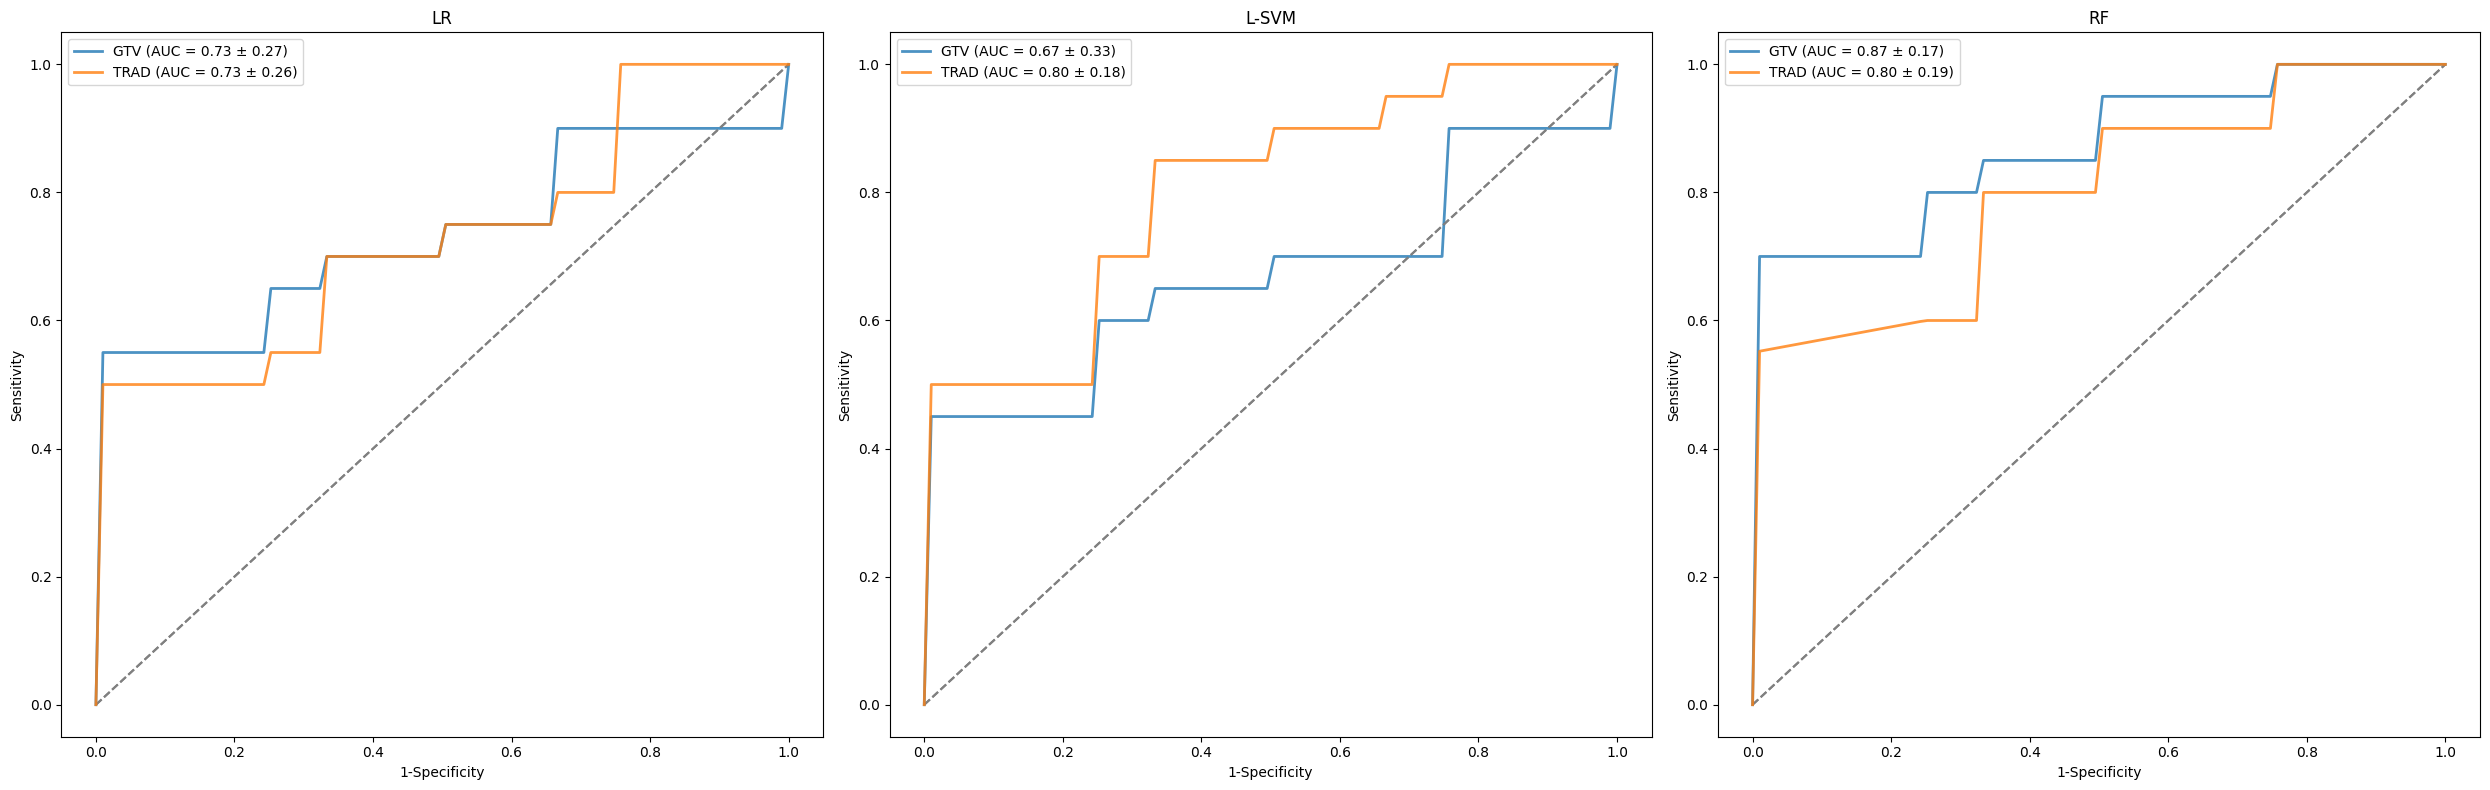

In [18]:
models = {
        'LR': LogisticRegression(penalty='none', max_iter=25_000),
        'L-SVM': SVC(probability=True),
        'RF': RandomForestClassifier(random_state=0)
        }

model_names = list(models.keys())


fig, axes = plt.subplots(1, 3, figsize=(25, 8))

roi_names = ["gtv", "trad"]

for estimator_name, estimator in models.items():

    for roi_name, df in {"gtv":featuresGTV_df, "trad":featuresTRAD_df}.items():
        
        ax = axes[model_names.index(estimator_name)]
        ax.set_title(estimator_name.upper())
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        
        selected_features = selected_signature[roi_name][estimator_name]
        piped_estimator = make_pipeline(StandardScaler(), estimator)
        
        X_df = df[selected_features]
        y_df = df["PD"]
        
        plot_cvroc(piped_estimator, X_df, y_df, cv = cv, ax=ax, label=roi_name.upper())
        
        ax.set_ylabel("Sensitivity")
        ax.set_xlabel("1-Specificity")
        ax.legend()
        
plt.tight_layout()
# plt.savefig("figures/roc_auc.tif", format="tiff", dpi=600)
plt.show()


### Exporting the Best Model Features and Predictions for Further Analysis

In [21]:
selected_signature

{'gtv': {'LR': ['original_glszm_SizeZoneNonUniformityNormalized',
   'original_gldm_LargeDependenceHighGrayLevelEmphasis',
   'original_gldm_DependenceVariance'],
  'L-SVM': ['original_glcm_MCC',
   'original_glcm_Imc1',
   'original_glszm_GrayLevelVariance'],
  'RF': ['original_shape_Flatness',
   'original_shape_MajorAxisLength',
   'original_ngtdm_Busyness']},
 'trad': {'LR': ['original_glcm_Imc1',
   'original_firstorder_InterquartileRange',
   'original_glcm_Imc2'],
  'L-SVM': ['original_firstorder_Median',
   'original_gldm_LargeDependenceLowGrayLevelEmphasis',
   'original_gldm_DependenceEntropy'],
  'RF': ['original_glcm_Imc1',
   'original_shape_MajorAxisLength',
   'original_glcm_MaximumProbability']}}

In [28]:
df

,pts_id,PD,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,...,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,A160402,1,0.713488,0.585897,44.998771,76.803276,86.648716,85.906926,94.868330,95.958324,...,0.129367,0.001675,0.163119,163.144627,0.000317,0.586614,0.000737,2554.790698,0.029802,1.909355
1,A170158,0,0.763783,0.678565,15.793409,23.274730,24.331050,31.622777,26.683328,31.685959,...,0.427159,0.006645,0.103112,24.290888,0.002794,0.160494,0.015522,166.179046,0.030937,5.223630
2,A170186,0,0.578847,0.403687,46.042920,114.055963,122.800651,122.000000,110.453610,124.482931,...,0.125093,0.001654,0.261504,276.215240,0.000443,0.820702,0.000533,4110.171943,0.066284,1.353264
3,A170659,0,0.519069,0.373159,10.204389,27.345976,27.784888,24.331050,18.973666,29.529646,...,1.807853,0.063820,0.136167,4.040520,0.024183,0.518660,0.031331,30.940536,0.061088,0.973438
4,A170727,1,0.159905,0.141436,11.550292,81.664315,17.204651,18.867962,55.461698,62.577951,...,1.785360,0.044316,0.089747,2.807569,0.008048,0.608943,0.033714,18.551539,0.067628,0.912335
5,A170741,1,0.664736,0.486880,16.331590,33.543370,27.784888,37.576588,32.984845,37.788887,...,0.089312,0.002797,0.185514,175.232765,0.001491,0.146941,0.005526,1196.123863,0.079162,6.325331
6,A170777,0,0.577760,0.503873,4.542968,9.016098,6.324555,8.944272,8.944272,9.797959,...,9.503289,0.415570,0.184108,1.642398,0.055281,0.509785,0.358371,3.501197,0.065147,1.450184
7,A171108,1,0.804217,0.504981,21.392149,42.362323,42.801869,50.159745,50.159745,52.573758,...,0.112278,0.003126,0.204794,141.709807,0.001020,0.214782,0.003975,1444.857178,0.064731,4.611938
8,A180028,1,0.626184,0.443679,18.243316,41.118240,41.231056,30.000000,45.694639,49.355851,...,0.087791,0.003560,0.294671,189.916375,0.001783,0.141874,0.006641,1824.833793,0.109576,5.462481
9,A181036,1,0.871195,0.572670,42.210893,73.708871,84.023806,86.833173,88.566359,95.414884,...,0.178033,0.002166,0.180952,135.649767,0.000531,0.828357,0.000638,2082.457036,0.027746,1.291432


In [37]:
pred_dfs = {}

best_estimator_name = 'RF'
cv = StratifiedKFold(n_splits=10, shuffle=False)

for roi_name, df in {'gtv':featuresGTV_df, 'trad':featuresTRAD_df}.items():
    
    pred_df = {}
    
    features = selected_signature[roi_name][best_estimator_name]
    
    X_df = df[features]
    y_df = df['PD']
    
    estimator = models[best_model]
    piped_estimator = make_pipeline(StandardScaler(), estimator)
    
    proba = cross_val_predict(piped_estimator, X_df, y_df, cv=cv, method="predict_proba")[:,1]
    
    pred_df['pid'] = df['pts_id'] 
    pred_df['roi'] = [roi_name] * len(df) 
    pred_df['true_pd'] = df['PD']
    pred_df['proba_pd'] = proba
    
    pred_df = dict(
        **{"pid": df['pts_id']},
        **{roi_name+"_"+feat: df[feat] for feat in features},
        **{'true_pd': df['PD'], roi_name+"_"+'proba_pd': proba}
    )
    
    pred_dfs[roi_name] = pd.DataFrame(pred_df)
    
    

In [48]:
pred_dfs["trad"][pred_dfs["trad"].pid=="A170158"]

,pid,trad_original_glcm_Imc1,trad_original_shape_MajorAxisLength,trad_original_glcm_MaximumProbability,true_pd,trad_proba_pd
1,A170158,-0.105385,22.774791,0.31662,0,0.1


In [49]:
pred_dfs["gtv"][pred_dfs["gtv"].pid=="A170158"]

,pid,gtv_original_shape_Flatness,gtv_original_shape_MajorAxisLength,gtv_original_ngtdm_Busyness,true_pd,gtv_proba_pd
1,A170158,0.678565,23.27473,0.160494,0,0.39


In [40]:
merge_on_column = 'pid'

overlap_cols = pred_dfs["gtv"].columns.intersection(pred_dfs["trad"].columns).drop(merge_on_column)
trad_clean = pred_dfs["trad"].drop(columns=overlap_cols)

pred_df = pred_dfs["gtv"].merge(trad_clean, on=merge_on_column, how='left')

In [55]:
column_order = ["pid"] + [feat for feat in pred_df.columns if "original" in feat] + ["true_pd", "gtv_proba_pd", "trad_proba_pd"]
pred_df = pred_df[column_order].reset_index(drop=True)


pred_df.to_csv("results/pred_df.csv", index=False)

### Statistical Utils

In [ ]:
## Confidence interval estimation using boostrapping

def get_bootstrap_sample(X_df, y_df, n_splits=2):
    """
    Returns a stratified bootstrap sample of X and y,
    preserving class proportions.
    """
    
    df = pd.concat([X_df, y_df], axis=1)
    
    while True:
        sampled_df = df.sample(n=len(df), replace=True).reset_index(drop=True)
        if sampled_df[y_df.name].sum()>=n_splits:
            break;

    return sampled_df[X_df.columns], sampled_df[y_df.name]


def percentile_bootstrap_ci(X_df, y_df, statistic, n_splits, n_iterations, alpha=0.05):
    
    true_statistic = statistic(X_df, y_df)
    
    assert np.isscalar(true_statistic), "the statistic method should return a scalar value"
    
    bootstrap_statistics = []
    
    for i in range(n_iterations):
        
        X_sample, y_sample = get_bootstrap_sample(X_df, y_df, n_splits) 
        estimate = statistic(X_sample, y_sample)
        bootstrap_statistics.append(estimate)

    ci_boot = np.quantile(bootstrap_statistics, [alpha/2, 1-(alpha/2)])
    
    return true_statistic, ci_boot, bootstrap_statistics

def bca_bootstrap_ci(X_df, y_df, statistic, bootstrap_statistics, alpha=0.05): #bias corrected and accelerated
    """
    Calculate Bias corrected and accelerated confidence intervals for a bootstrap distribution.
    
    https://www.tau.ac.il/~saharon/Boot/10.1.1.133.8405.pdf
    
    equations: https://www.erikdrysdale.com/bca_python/
    
    Parameters:
        X_df the dataframe with features
        y_df the pandas series with values
        statistic: the function that will return a scalar estimate of the statistic of interest
        bootstrapped_statistics: Array of bootstrap statistics.
        alpha: Significance level (default 0.05 for 95% CI).
    
    Returns:
        Lower and upper bounds of the confidence interval.
    """
    # Sort the bootstrap statistics
    
    true_statistic = statistic(X_df, y_df)
    assert np.isscalar(true_statistic), "the statistic function should return a scalar value"
    
    # bootstrap_statistics = np.append(bootstrap_statistics, true_statistic) 
    bootstrap_statistics = np.sort(bootstrap_statistics)
    B = len(bootstrap_statistics)

    # Bias correction factor (z0)
    # https://github.com/scipy/scipy/blob/v1.16.2/scipy/stats/_resampling.py#L73
    ## Option 1
    prop = ((bootstrap_statistics < true_statistic).sum() + (bootstrap_statistics <= true_statistic).sum()) / (2*B) 
    prop = np.clip(prop, 0.1, 0.9) #this prevent weird answers for extremely skewed bootstrap distributions
    z0 = special.ndtri(prop)
    
    ##Option 2
    # prop = np.mean(bootstrap_statistics < true_statistic)
    # z0 = special.ndtri(prop)
    
    # Acceleration constant (a)
    # jackknife estimates (leave one out)
    jackknife_estimates = np.array([statistic(X_df.drop(index=i, inplace=False), y_df.drop(index=i, inplace=False)) 
                                    for i in X_df.index])
    mean_jackknife = np.mean(jackknife_estimates)
    
    num = np.sum((mean_jackknife - jackknife_estimates) ** 3)
    den = (6 * np.sum((mean_jackknife - jackknife_estimates) ** 2) ** 1.5)
    a =  num/den if den!=0 else 0.0 

    ## Option 1: Adjusted percentiles
    # z_alpha_low = stats.norm.ppf(alpha / 2)  # Lower z-score
    # z_alpha_high = stats.norm.ppf(1 - alpha / 2)  # Upper z-score
    
    # lower_percentile = stats.norm.cdf(z0 + ((z0 + z_alpha_low) / (1 - a * (z0 + z_alpha_low))))
    # upper_percentile = stats.norm.cdf(z0 + ((z0 + z_alpha_high) / (1 - a * (z0 + z_alpha_high))))
    
    # ci = np.quantile(bootstrap_statistics, [lower_percentile, upper_percentile])
    
    ## Option 2:
    z_alpha = special.ndtri(alpha)
    z_1alpha = -z_alpha
    
    num1 = z0 + z_alpha
    alpha_1 = special.ndtr(z0 + num1/(1 - a*num1))
    num2 = z0 + z_1alpha
    alpha_2 = special.ndtr(z0 + num2/(1 - a*num2))
    
    ci = np.quantile(bootstrap_statistics, [alpha_1, alpha_2])

   
    return true_statistic, ci, bootstrap_statistics


## Permutation test
def permutation_test(X_df, y_df, statistic, n_iterations):
    
    true_statistic = statistic(X_df, y_df)
    perm_statistics = [true_statistic]
    
    for i in range(n_iterations-1):
        perm_y_df = y_df.sample(frac=1).reset_index(drop=True)
        estimate = statistic(X_df, perm_y_df)
        
        perm_statistics.append(estimate)
        
    return np.mean(np.abs(perm_statistics)>=np.abs(true_statistic)), perm_statistics    


## Delong's test
def compare_aucs(probs1, probs2, targets):

    z_score, p_value = Delong_test(targets, probs1, probs2)
    
    return p_value
    

### Statistical Analysis

In [ ]:
def cross_val_metric(piped_model, cv, metric):
    def call_fn(X_df, y_df):
        return np.mean(cross_val_score(piped_model, X_df, y_df, scoring=metric, cv=cv))
    return call_fn

In [ ]:
n_boot = 10_000
n_perm = 1000

cv = StratifiedKFold(n_splits=10, shuffle=False)
metric = "roc_auc"
num_feats = 3


models = {
'LR': LogisticRegression(penalty='none', max_iter=25_000),
'L-SVM': SVC(probability=True),
'RF': RandomForestClassifier(random_state=0)
}

fig_boot, boot_axes = plt.subplots(2, 3, figsize=(25, 8))
fig_perm, perm_axes = plt.subplots(2, 3, figsize=(25, 8))


perm_dist = {"gtv":{}, "trad":{}}
boot_dist = {"gtv":{}, "trad":{}}

stat_df = {"model":[], "roi":[], "signature":[], "estimate":[], "percentile_95%CI":[], "bca_95%CI":[], "p_value":[]}
for roi_name, df in {"gtv":featuresGTV_df, "trad":featuresTRAD_df}.items():
    
    print("*"*10)
    print(roi_name)
    print("*"*10)
    
    for model_name, model in models.items():
        
        print(f"Evaluating {model_name} on {roi_name} dataset...")
        piped_model = make_pipeline(StandardScaler(), model)
        selected_features = selected_signature[roi_name][model_name]
        
        print("Features:")
        print(selected_features)
        
        X_df = df[selected_features]
        y_df = df['PD']
    
        true_estimate, percentile_ci, boot_values = percentile_bootstrap_ci(X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric="roc_auc"), n_splits = cv.n_splits, n_iterations=n_boot)
        print("percentile ci:", true_estimate, percentile_ci, "boot_mean:", np.mean(boot_values))
        true_estimate, bca_ci,boot_values = bca_bootstrap_ci(X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric=metric), bootstrap_statistics=boot_values)
        print("bca ci:", true_estimate, bca_ci)
        mean_boot = np.mean(boot_values)
        lower_ci, upper_ci = bca_ci
        
        p_value, perm_values = permutation_test(X_df, y_df, statistic=cross_val_metric(piped_model, cv=cv, metric=metric), n_iterations=n_perm)
        
        print("p_value:", p_value)
        
        stat_df["model"].append(model_name)
        stat_df["roi"].append(roi_name)
        stat_df["signature"].append(selected_features)
        stat_df["estimate"].append(true_estimate)
        stat_df["percentile_95%CI"].append(percentile_ci)
        stat_df["bca_95%CI"].append(bca_ci)
        stat_df["p_value"].append(p_value)
        
        perm_dist[roi_name][model_name] = perm_values
        boot_dist[roi_name][model_name] = boot_values
        
        boot_ax = boot_axes[roi_names.index(roi_name), model_names.index(model_name)]
        boot_ax.hist(boot_values, histtype='step')
        boot_ax.axvline(true_estimate, color='orange', linestyle='-', linewidth=2, label=f'Observed AUC: {true_estimate:0.2f}')
        boot_ax.axvline(mean_boot, color='blue', linestyle='--', linewidth=2, label=f'Bootstrap AUC Mean: {mean_boot:0.2f}')
        boot_ax.axvline(lower_ci, color='green', linestyle=':', linewidth=2, label=f'95% BCa CI: [{lower_ci:0.2f}, {upper_ci:0.2f}]')
        boot_ax.axvline(upper_ci, color='green', linestyle=':', linewidth=2)
        
        boot_ax.set_title(f"{roi_name.upper()}+{model_name}")
        boot_ax.set_xlabel("AUC")
        boot_ax.set_ylabel("Count")
        boot_ax.legend(loc='upper left')
        
        perm_ax = perm_axes[roi_names.index(roi_name), model_names.index(model_name)]
        perm_ax.hist(perm_values, histtype='step')
        perm_ax.axvline(true_estimate, color='orange', linestyle='-', linewidth=2, label=f'True AUC: {true_estimate:0.2f} (p={p_value:0.3f})')
        
        perm_ax.set_title(f"{roi_name.upper()}+{model_name}")
        perm_ax.set_xlabel("AUC")
        perm_ax.set_ylabel("Count")
        perm_ax.legend()
        
        
        

    
stat_df = pd.DataFrame(stat_df)
stat_df.to_csv(os.path.join("results", "stat_df.csv"), index=False)

np.save(os.path.join("results", "perm_dist.npy"), perm_dist, allow_pickle=True)
np.save(os.path.join("results", "boot_dist.npy"), boot_dist, allow_pickle=True)


fig_boot.tight_layout()
fig_boot.savefig("figures/bootstrap_plot.tif", format="tiff", dpi=600)    

fig_perm.tight_layout()
fig_perm.savefig("figures/permutation_plot.tif", format="tiff", dpi=600)   

plt.show()

DeLong's Test

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=False)

models = {
    'LR': LogisticRegression(penalty='none', max_iter=25_000),
    'L-SVM': SVC(probability=True),
    'RF': RandomForestClassifier(random_state=0)
    }

featuresGTV_df = featuresGTV_df.sort_values(by="pts_id").reset_index(drop=True)
featuresTRAD_df = featuresTRAD_df.sort_values(by="pts_id").reset_index(drop=True)

assert all(featuresGTV_df["pts_id"] == featuresTRAD_df["pts_id"]), "DataFrames must have the same patient order!"

targets = featuresGTV_df["PD"]

for model_name, model in models.items():
    method="predict_proba"
    if model_name=="L-SVM":
        method = "decision_function"
    

    probs_gtv = cross_val_predict(make_pipeline(StandardScaler(), model), featuresGTV_df[selected_signature["gtv"][model_name]], featuresGTV_df["PD"], cv=cv, method=method)
    probs_trad = cross_val_predict(make_pipeline(StandardScaler(), model), featuresTRAD_df[selected_signature["trad"][model_name]], featuresTRAD_df["PD"], cv=cv, method=method)
    
    if method=="predict_proba":
        probs_gtv = probs_gtv[:,1]
        probs_trad = probs_trad[:,1]
    
    print(model_name, compare_aucs(probs_gtv, probs_trad, targets))


### Correlation Analysis

In [ ]:
def mwm(feats1_df, feats2_df, corr_method='pearson'):
    
    # make sure that feats1_df and feats2_df was sorted based on patient_id before calling this function
    
    feats1_df = feats1_df.add_prefix("feats1_")
    feats2_df = feats2_df.add_prefix("feats2_")
    
    f1_k = feats1_df.columns.to_list()
    f2_k = feats2_df.columns.to_list()
    
    feats_df = pd.concat([feats1_df, feats2_df], axis=1)

    f = list(set(f1_k) | set(f2_k))
    corr_matrix = feats_df[f].corr(method=corr_method).abs()
    cost_matrix = corr_matrix.loc[f1_k, f2_k]
    
    row_ind, col_ind = linear_sum_assignment(cost_matrix, maximize=True)

    return cost_matrix.values[row_ind, col_ind].sum()/len(f1_k) # or len(f2_k)

In [ ]:
import itertools
    
fs_methods = ['LR', 'L-SVM', 'RF']
rois = ["GTV", "TRAD"]

elements = [roi+"+"+method for roi in rois for method in fs_methods]


pearson_corr_df = pd.DataFrame(np.zeros((len(elements), len(elements))), index=elements, columns=elements)
spearman_corr_df = pd.DataFrame(np.zeros((len(elements), len(elements))), index=elements, columns=elements)
pairs = list(itertools.product(elements, repeat=2))

for p1, p2 in pairs:
    
    p1_roi, p1_method = p1.split("+")
    p2_roi, p2_method = p2.split("+")
    
    
    p1_signature = selected_signature[p1_roi.lower()][p1_method]
    p2_signature = selected_signature[p2_roi.lower()][p2_method]
    
    p1_df = featuresGTV_df if p1_roi=="GTV" else featuresTRAD_df
    p2_df = featuresGTV_df if p2_roi=="GTV" else featuresTRAD_df
    
    pearson_cost = mwm(p1_df[p1_signature], p2_df[p2_signature], corr_method="pearson")
    pearson_corr_df.loc[p1, p2] = pearson_cost
    
    spearman_cost = mwm(p1_df[p1_signature], p2_df[p2_signature], corr_method="spearman")
    spearman_corr_df.loc[p1, p2] = spearman_cost



In [ ]:
# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# --- Left: Pearson ---
ax1 = axes[0]
hm1 = sns.heatmap(
    pearson_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax1
)
ax1.set_title("Pearson Correlation")


# --- Right: Spearman ---
ax2 = axes[1]
hm2 = sns.heatmap(
    spearman_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax2
)
ax2.set_title("Spearman Correlation")


# --- Add ONE shared colorbar ---
cbar = fig.colorbar(hm2.collections[0], ax=axes, shrink=0.75, location='right')
# cbar.set_label("Correlation", fontweight='bold')


plt.savefig("figures/corr_plot.tif", format="tiff", dpi=600)
plt.show()


In [ ]:

# Create figure and axes
fig, axes = plt.subplots(1, 1, figsize=(20, 8))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# --- Left: Pearson ---
ax1 = axes
hm1 = sns.heatmap(
    spearman_corr_df, cmap=cmap, square=True, linewidth=0.5,
    annot=True, vmin=0, vmax=1, cbar=False, ax=ax1
)
ax1.set_title("Spearman Correlation")


# --- Add ONE shared colorbar ---
cbar = fig.colorbar(hm1.collections[0], ax=axes, shrink=0.75, location='right')
# cbar.set_label("Correlation", fontweight='bold')


plt.savefig("figures/spearman_corr_plot.tif", format="tiff", dpi=600)
plt.show()
